La transofrmation des données permet de normaliser et standardiser les données brutes. Ces transformation permettent de mettre à l'échelle des charactéristiques mais aussi d'éviter du surapprentissage lors de l'utilisation de modèle de machine learning de type regression et classification. Prenons par exemple le jeu de données d'exemple de scikit-learn et observons pour les données "SalesPrice" et "YearBuilt". Nous en profiterons pour calculer la mesure d'asymétrie à l'aide de la méthode skew de pandas. 
- Un skewness de 0 indique une distribution parfaitement symétrique (comme une courbe normale).
- Un skewness positif indique que la queue droite de la distribution (les valeurs plus grandes) est plus longue ou plus étalée que la queue gauche (les valeurs plus petites).
- Un skewness négatif indique que la queue gauche est plus longue ou plus étalée que la queue droite.

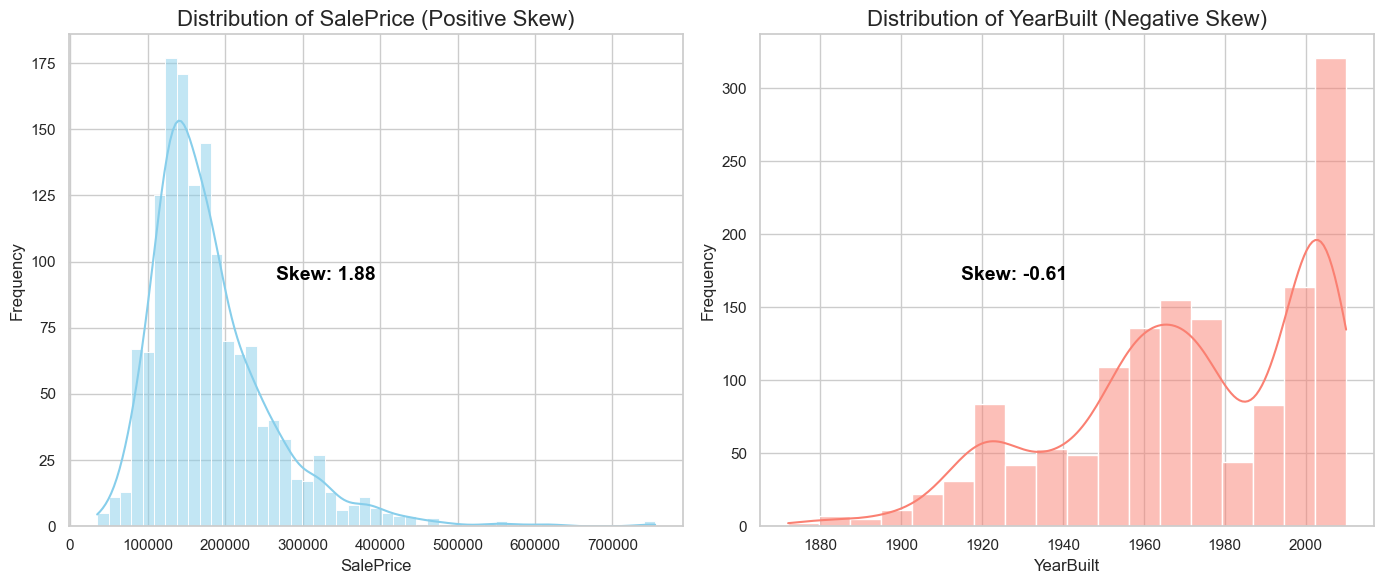

In [8]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import QuantileTransformer

# Load the dataset
Ames = pd.read_csv('ames_housing_no_missing.csv')

# Calculate skewness
sale_price_skew = Ames['SalePrice'].skew()
year_built_skew = Ames['YearBuilt'].skew()

# Set the style of seaborn
sns.set(style='whitegrid')

# Create a figure for 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot for SalePrice (positively skewed)
sns.histplot(Ames['SalePrice'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of SalePrice (Positive Skew)', fontsize=16)
ax[0].set_xlabel('SalePrice')
ax[0].set_ylabel('Frequency')
# Annotate Skewness
ax[0].text(0.5, 0.5, f'Skew: {sale_price_skew:.2f}', transform=ax[0].transAxes,
           horizontalalignment='right', color='black', weight='bold',
           fontsize=14)

# Plot for YearBuilt (negatively skewed)
sns.histplot(Ames['YearBuilt'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribution of YearBuilt (Negative Skew)', fontsize=16)
ax[1].set_xlabel('YearBuilt')
ax[1].set_ylabel('Frequency')
# Annotate Skewness
ax[1].text(0.5, 0.5, f'Skew: {year_built_skew:.2f}', transform=ax[1].transAxes,
           horizontalalignment='right', color='black', weight='bold',
           fontsize=14)

plt.tight_layout()
plt.show()

Pour « SalePrice », le graphique montre une distribution fortement biaisée vers la droite. De telles distributions peuvent compliquer la modélisation prédictive. En revanche, « YearBuilt » montre une asymétrie négative, où la distribution révèle que les maisons les plus récentes prédominent, les maisons plus anciennes formant la longue queue à gauche.

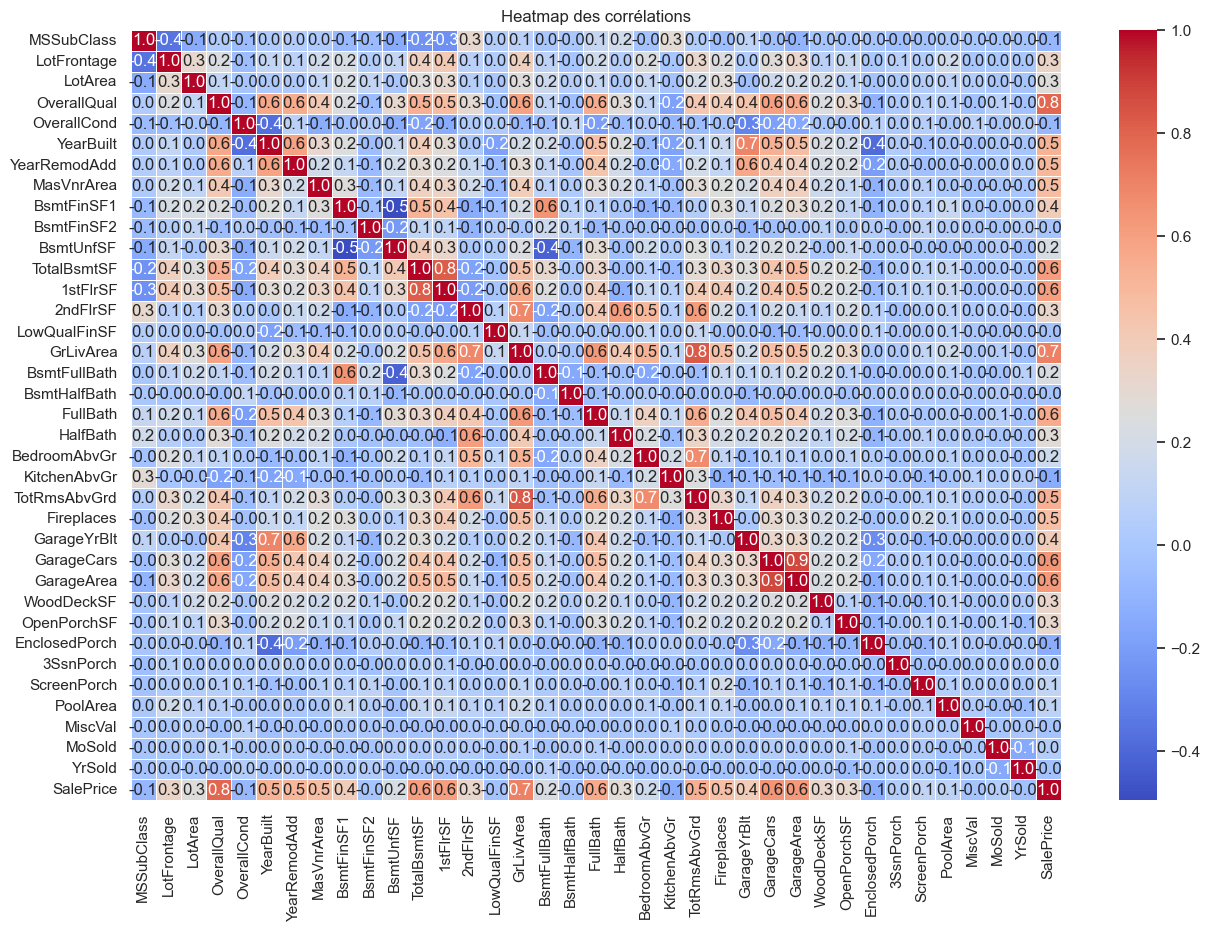

In [18]:
# Exemple : Calculer la corrélation pour les colonnes numériques
numeric_cols = Ames.select_dtypes(include=[float, int])
corr_matrix = numeric_cols.corr()

# Tracer une heatmap avec Seaborn
plt.figure(figsize=(15, 10))  # Ajuster la taille de la figure
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.5)

# Afficher la heatmap
plt.title('Heatmap des corrélations')
plt.show()

In [ ]:
print("hello")